# TASK_5 : Advanced Analysis

In [1]:
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Data = pd.read_csv(r"C:\Users\Zeeshii_96\Desktop\SaiketSystem_InternOfferLetter\Telco_Customer_Churn_Dataset  (3).csv")
Data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
#Checking Data Types
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
#Checking Null Values
Data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
#Checking the White Spaces
(Data['TotalCharges'] == " ").sum()

np.int64(11)

In [6]:
#Replacing those 11 spaces with Under_scores
Data['TotalCharges'] = Data['TotalCharges'].replace(" ","_")

In [7]:
#Spaces are Cleaned
(Data['TotalCharges'] == " ").sum()

np.int64(0)

In [8]:
Data['TotalCharges'].dtype

dtype('O')

In [9]:
#Conversion to numeric terms
Data["TotalCharges"] = pd.to_numeric(Data["TotalCharges"], errors="coerce")

In [10]:
#Converted
Data['TotalCharges'].dtype

dtype('float64')

In [11]:
#Eliminating Missing Rows
Data = Data.dropna()

In [12]:
Data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
Data.duplicated().sum() #Hence there are No duplicates ELSE we could do Data = Data.drop_duplicates()

np.int64(0)

In [14]:
#Converts names to lowercase
#Replaces spaces with '_'
Data.columns = Data.columns.str.lower().str.replace(" ","_")

In [15]:
Data["churn"] = Data["churn"].replace({1 : "Yes", 0 : "No"})

In [16]:
Data['churn'].reset_index()

,index,churn
0,0,No
1,1,No
2,2,Yes
3,3,No
4,4,Yes
...,...,...
7027,7038,No
7028,7039,No
7029,7040,No
7030,7041,Yes


In [17]:
churn_counts = Data['churn'].value_counts().reset_index()
churn_counts

,churn,count
0,No,5163
1,Yes,1869


### Visualization of Hist and Box plots

#### Churn Distribution Analysis
Firstly , We analyze how many customers stayed vs left.

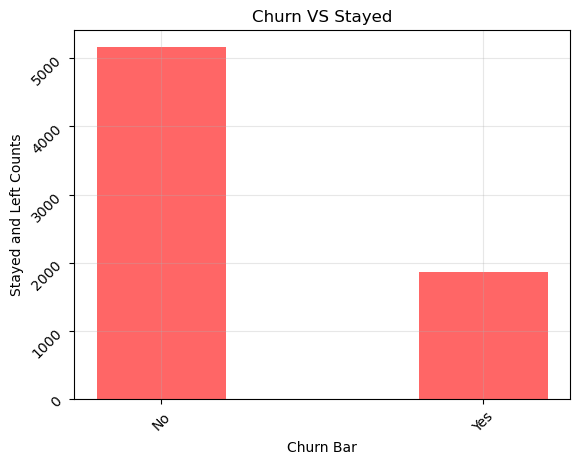

In [18]:
plt.bar(churn_counts["churn"] ,churn_counts["count"] , width = 0.4 ,  color = "red" , alpha = 0.6 , align = "center")
plt.title("Churn VS Stayed")
plt.xlabel("Churn Bar")
plt.ylabel("Stayed and Left Counts")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.grid(alpha=0.3)
plt.show()


## Insight:¶
The majority of customers have not churned, indicating good customer retention. However, a significant portion of customers have left, highlighting the need for further analysis to identify factors contributing to churn.

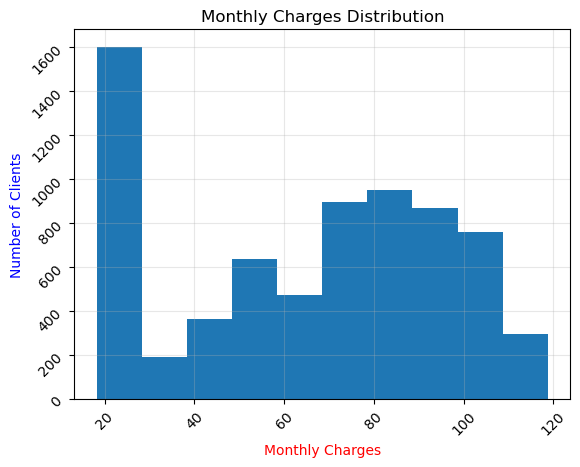

In [19]:
plt.hist(Data["monthlycharges"])
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges", color = 'red')
plt.ylabel("Number of Clients" , color = 'blue')
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.grid(alpha=0.3)
plt.show()

## Insight:
The histogram shows the distribution of monthly charges among customers. 
Most customers fall within the medium to high charge range (around 70–100), 
while fewer customers are in the low and very high charge ranges.

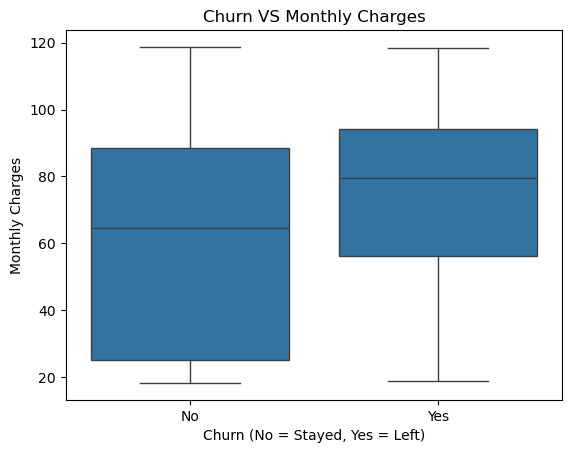

In [20]:
sns.boxplot(x = 'churn' , y = 'monthlycharges' , data = Data)
plt.title("Churn VS Monthly Charges")
plt.xlabel("Churn (No = Stayed, Yes = Left)")
plt.ylabel("Monthly Charges")
plt.show()

## Insight:
The boxplot shows that customers who churn (Yes) have higher monthly charges 
compared to those who stay (No). This indicates that higher-paying customers 
are more likely to leave, possibly due to expensive plans or dissatisfaction 
with pricing.

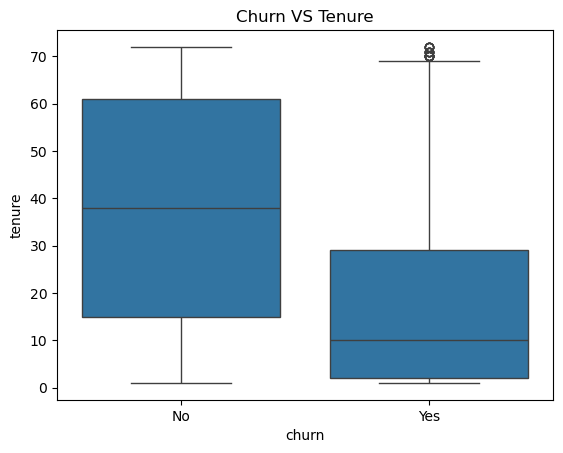

In [21]:
sns.boxplot(x = "churn", y = "tenure", data = Data)
plt.title("Churn VS Tenure")
plt.show()

In [22]:
counts = Data['churn'].value_counts()
percent = Data["churn"].value_counts(normalize = True).mul(100).round(2)

#Converting to Table Format using DataFrame

churn_table = pd.DataFrame({
    "Churn" : counts.index,
    "Count" : counts.values,
    "Percentage": percent.values
})
    
churn_table

,Churn,Count,Percentage
0,No,5163,73.42
1,Yes,1869,26.58


## Insight:
Approximately 27% of customers have churned, while around 73% have stayed. 
The boxplot shows that most churned customers have low tenure (around 0–20 months), 
indicating that new customers are more likely to leave. However, a few long-term 
customers (up to ~70 months) also churn, as seen in the outliers.

In [23]:
Data.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
#Grouping Clients Based on how long they stayed
Data["tenure_group"] = pd.cut(Data["tenure"], bins = [0,12,36,72], labels = ["0-12", "13-36", "37+"])
Data["tenure_group"]

0        0-12
1       13-36
2        0-12
3         37+
4        0-12
        ...  
7038    13-36
7039      37+
7040     0-12
7041     0-12
7042      37+
Name: tenure_group, Length: 7032, dtype: category
Categories (3, object): ['0-12' < '13-36' < '37+']

In [25]:
tenure_table = Data["tenure_group"].value_counts().reset_index()
tenure_table


,tenure_group,count
0,37+,3001
1,0-12,2175
2,13-36,1856


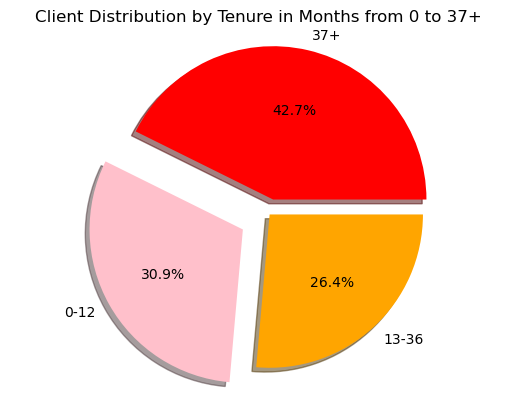

In [26]:
plt.pie(tenure_table["count"] , labels = tenure_table["tenure_group"],  explode = [0.1,0.2,0] ,autopct = '%1.1f%%' , colors = ['red','pink','orange'] , shadow = True )
plt.axis('equal')
plt.title("Client Distribution by Tenure in Months from 0 to 37+")
plt.show()

In [27]:
avg_charges = Data.groupby("tenure_group")["monthlycharges"].mean().reset_index().round(2)
avg_charges

,tenure_group,monthlycharges
0,0-12,56.17
1,13-36,63.25
2,37+,72.01


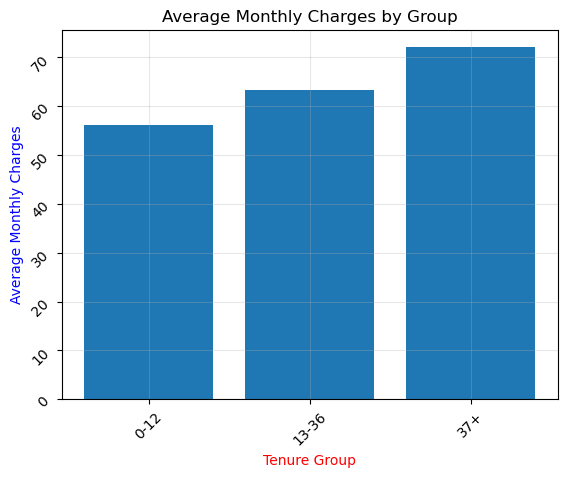

In [28]:
plt.bar(avg_charges["tenure_group"], avg_charges["monthlycharges"])
plt.title("Average Monthly Charges by Group")
plt.xlabel("Tenure Group", color = 'red')
plt.ylabel("Average Monthly Charges" , color = 'blue')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.grid(alpha = 0.3)
plt.show()

## Insight:
The bar chart shows that long-term customers (37+ months) pay higher monthly charges 
compared to new customers (0–12 months). This indicates that loyal customers tend to 
subscribe to more expensive or premium services.

In [37]:
Data.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,13-36
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37+
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12


# Step 1 : Churn by Tenure Group

In [34]:
#Making out the percentages amoung groups
churn_tenure = Data.groupby("tenure_group")["churn"].value_counts(normalize = True).mul(100).round(1).reset_index()
churn_tenure

,tenure_group,churn,proportion
0,0-12,No,52.3
1,0-12,Yes,47.7
2,13-36,No,74.5
3,13-36,Yes,25.5
4,37+,No,88.1
5,37+,Yes,11.9


In [43]:
churn_Yes = churn_tenure.loc[churn_tenure["churn"] == "Yes"]
churn_Yes

,tenure_group,churn,proportion
1,0-12,Yes,47.7
3,13-36,Yes,25.5
5,37+,Yes,11.9


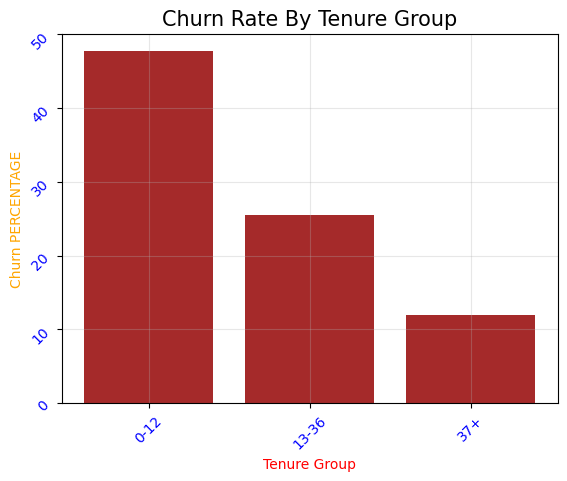

In [54]:
plt.bar(churn_Yes["tenure_group"], churn_Yes["proportion"], color = "brown")
plt.title("Churn Rate By Tenure Group" , size = 15)
plt.xlabel("Tenure Group" , color = 'red')
plt.ylabel("Churn PERCENTAGE" , color = 'orange')
plt.xticks(rotation=45 , color = 'blue')
plt.yticks(rotation=45 , color = 'blue')
plt.grid(alpha = 0.3)
plt.show()

## Insight:
The churn rate is highest among new customers (0–12 months) at around 47%, 
followed by medium-term customers (13–36 months) at around 25%, and lowest 
among long-term customers (37+ months) at around 11%. This shows that 
customer churn decreases as tenure increases.

# Step 2 : Churn by Gender

In [58]:
churn_gender = Data.groupby("gender")["churn"].value_counts(normalize = True).mul(100).round(1).reset_index()
churn_gender

,gender,churn,proportion
0,Female,No,73.0
1,Female,Yes,27.0
2,Male,No,73.8
3,Male,Yes,26.2


In [62]:
churn_yes_gender = churn_gender.loc[churn_gender["churn"] == "Yes"]
churn_yes_gender

,gender,churn,proportion
1,Female,Yes,27.0
3,Male,Yes,26.2


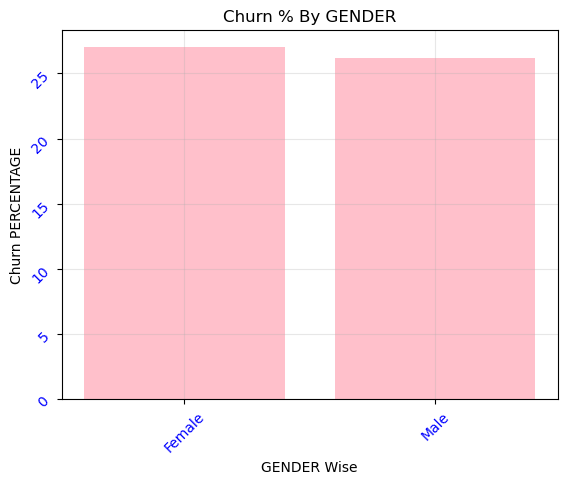

In [63]:
plt.bar(churn_yes_gender["gender"] , churn_yes_gender["proportion"] , color = 'pink')
plt.title("Churn % By GENDER")
plt.xlabel("GENDER Wise")
plt.ylabel("Churn PERCENTAGE")
plt.xticks(rotation=45 , color = 'blue')
plt.yticks(rotation=45 , color = 'blue')
plt.grid(alpha = 0.3)
plt.show()

## Insight
Churn rate is almost similar for both genders(Female = 27% / Male = 26%) , indicating gender 
does not significantly impact customer churn.

# Step 3 : Churn by Payment Method

In [66]:
churn_payment = Data.groupby("paymentmethod")["churn"].value_counts(normalize = True).mul(100).round(2).reset_index()
churn_payment

,paymentmethod,churn,proportion
0,Bank transfer (automatic),No,83.27
1,Bank transfer (automatic),Yes,16.73
2,Credit card (automatic),No,84.75
3,Credit card (automatic),Yes,15.25
4,Electronic check,No,54.71
5,Electronic check,Yes,45.29
6,Mailed check,No,80.80
7,Mailed check,Yes,19.20


In [69]:
churn_yes_payment = churn_payment.loc[churn_payment["churn"] == "Yes"]
churn_yes_payment

,paymentmethod,churn,proportion
1,Bank transfer (automatic),Yes,16.73
3,Credit card (automatic),Yes,15.25
5,Electronic check,Yes,45.29
7,Mailed check,Yes,19.20


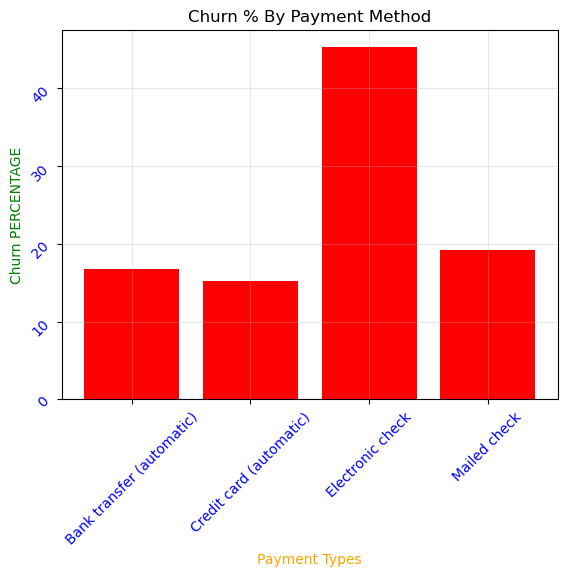

In [72]:
plt.bar(churn_yes_payment["paymentmethod"] , churn_yes_payment["proportion"] , color = 'red')
plt.title("Churn % By Payment Method")
plt.xlabel("Payment Types" , color = 'orange')
plt.ylabel("Churn PERCENTAGE" , color = 'green')
plt.xticks(rotation=45 , color = 'blue')
plt.yticks(rotation=45 , color = 'blue')
plt.grid(alpha = 0.3)
plt.show()

## Insight:
The analysis reveals a clear difference in churn behavior across payment methods. 
Customers using electronic check exhibit a significantly higher churn rate compared 
to those using automatic payment options such as bank transfers or credit cards. 
This suggests that customers on electronic check may experience lower engagement, 
less convenience, or potential dissatisfaction with the service. In contrast, 
customers enrolled in automatic payment methods tend to be more stable and less 
likely to leave, indicating stronger customer commitment and retention.

# Final Summary:
### The advanced analysis shows that churn is highest among new customers and 
### decreases as customer tenure increases, indicating that early customer 
### experience plays a critical role in retention. Gender does not have a 
### significant impact on churn, as both male and female customers show similar 
### behavior. However, payment method has a noticeable influence, with customers 
### using electronic check showing higher churn rates compared to those using 
### automatic payment options. These insights suggest that improving onboarding 
### experience and encouraging automated payment methods can help reduce churn.